In [32]:
import pandas as pd

# Загрузка данных
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Преобразование в DataFrame для удобства
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df['species'] = y
iris_df['species'] = iris_df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})


# Вывод первых строк данных
print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [33]:
# Статистическое описание данных
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Разведочный анализ данных (EDA)

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


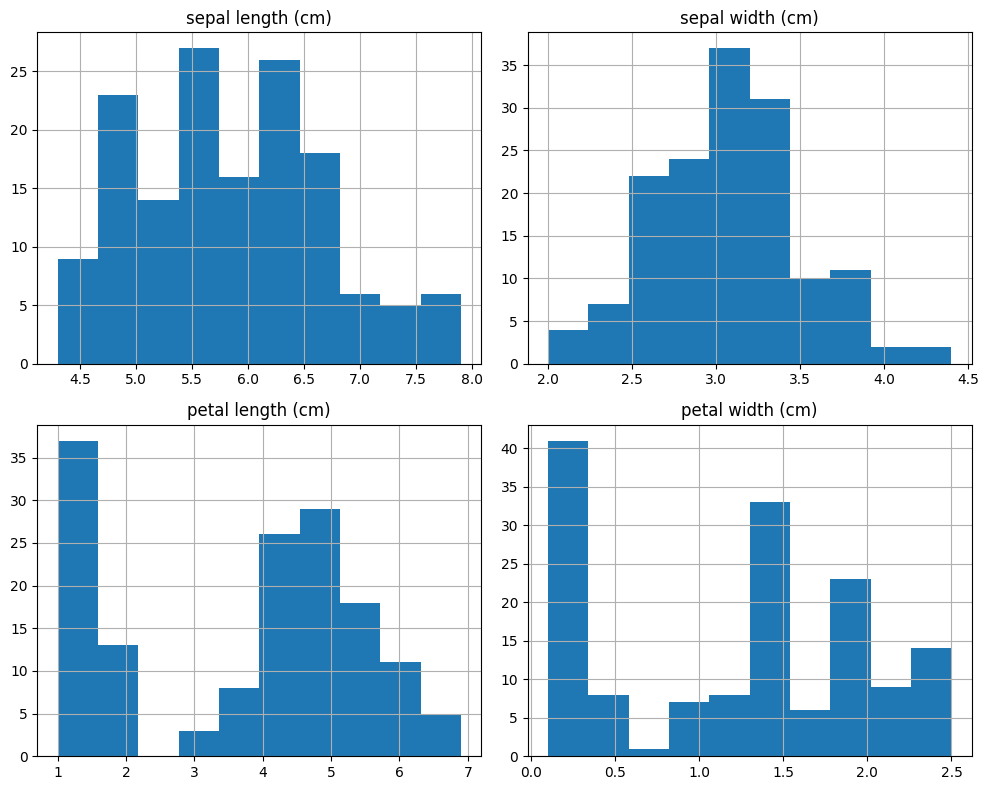

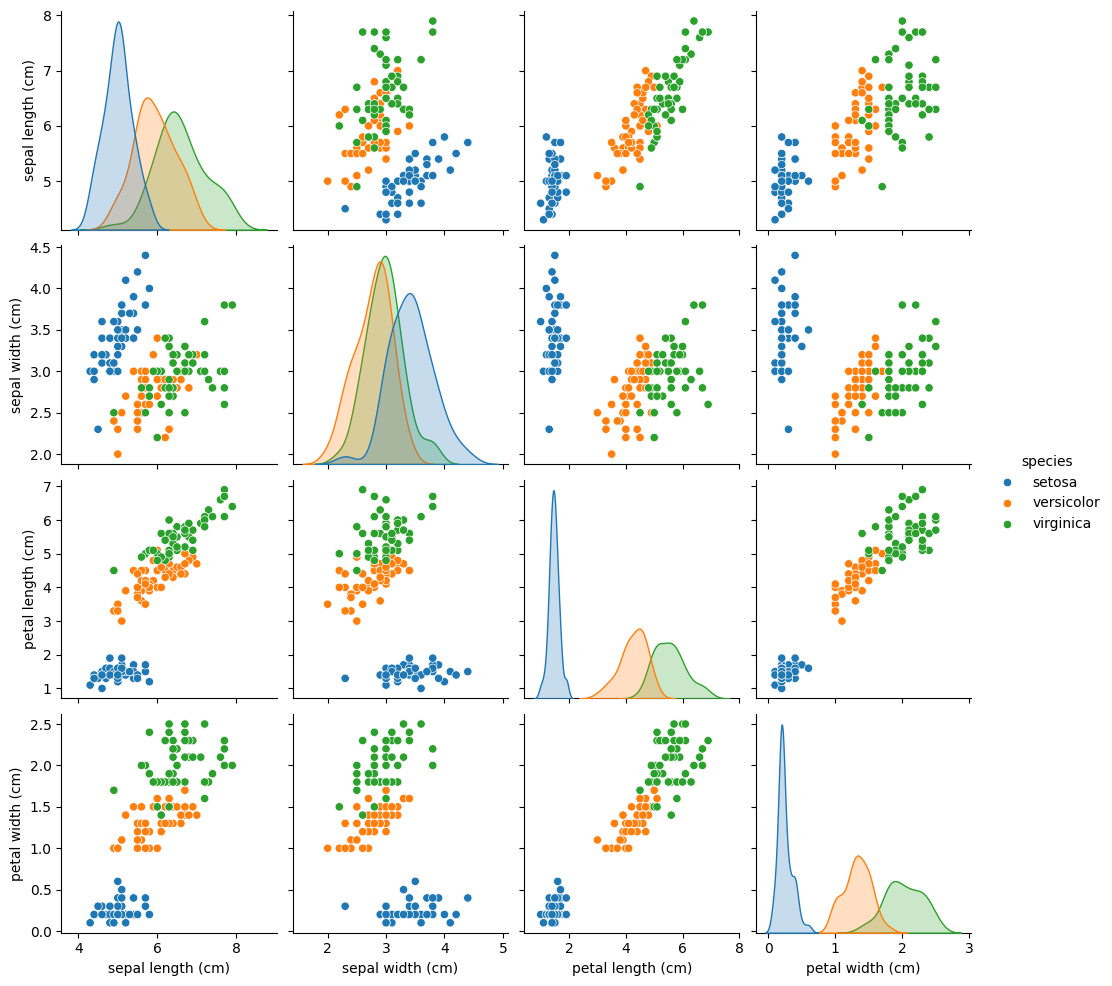

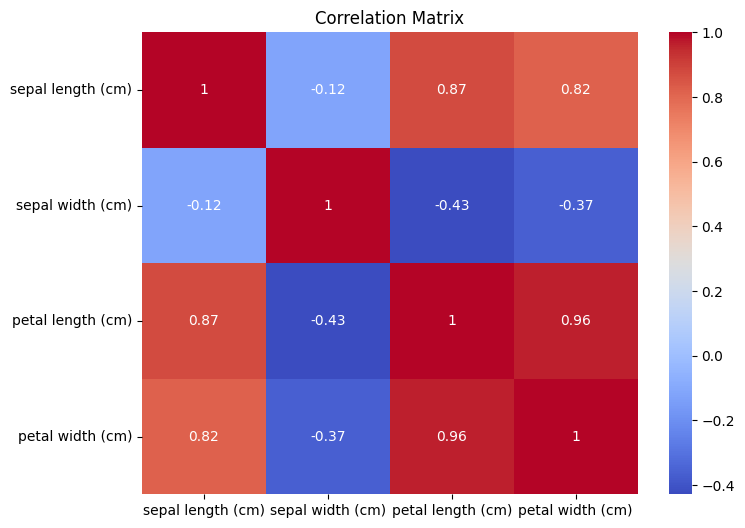

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Статистическое описание данных (только числовые признаки)
print(iris_df.describe())

# Гистограммы признаков (только числовые)
iris_df.drop('species', axis=1).hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

# Матрица scatter plot
sns.pairplot(iris_df, hue='species')
plt.show()

# Корреляционная матрица (исключаем столбец 'species')
plt.figure(figsize=(8, 6))
sns.heatmap(iris_df.drop('species', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Подготовка данных

In [35]:
from sklearn.model_selection import train_test_split

# Разделение на признаки и целевую переменную
X = iris_df.drop('species', axis=1)
y = iris_df['species']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Масштабирование данных
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Обучение моделей

Логистическая регрессия

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

lr = LogisticRegression(max_iter=200)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

print("Logistic Regression Results:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Results:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.87        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Accuracy: 0.9111111111111111


In [37]:
# Демонстрация переобучения на искусственных данных
print("=" * 70)
print("ДЕМОНСТРАЦИЯ ПЕРЕОБУЧЕНИЯ ЛИНЕЙНОЙ РЕГРЕССИИ")
print("=" * 70)

# Создаем искусственные данные для демонстрации переобучения
np.random.seed(42)
n_samples = 30
X_demo = np.linspace(0, 1, n_samples).reshape(-1, 1)

# Истинная функция: синус с добавлением шума
y_demo = np.sin(2 * np.pi * X_demo).ravel() + np.random.normal(0, 0.1, n_samples)

# Разделяем на обучающую и тестовую выборки
X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X_demo, y_demo, test_size=0.4, random_state=42
)

print(f"Размер обучающей выборки: {X_train_demo.shape[0]} образцов")
print(f"Размер тестовой выборки: {X_test_demo.shape[0]} образцов")
print(f"Истинная функция: f(x) = sin(2πx) + шум")

ДЕМОНСТРАЦИЯ ПЕРЕОБУЧЕНИЯ ЛИНЕЙНОЙ РЕГРЕССИИ
Размер обучающей выборки: 18 образцов
Размер тестовой выборки: 12 образцов
Истинная функция: f(x) = sin(2πx) + шум


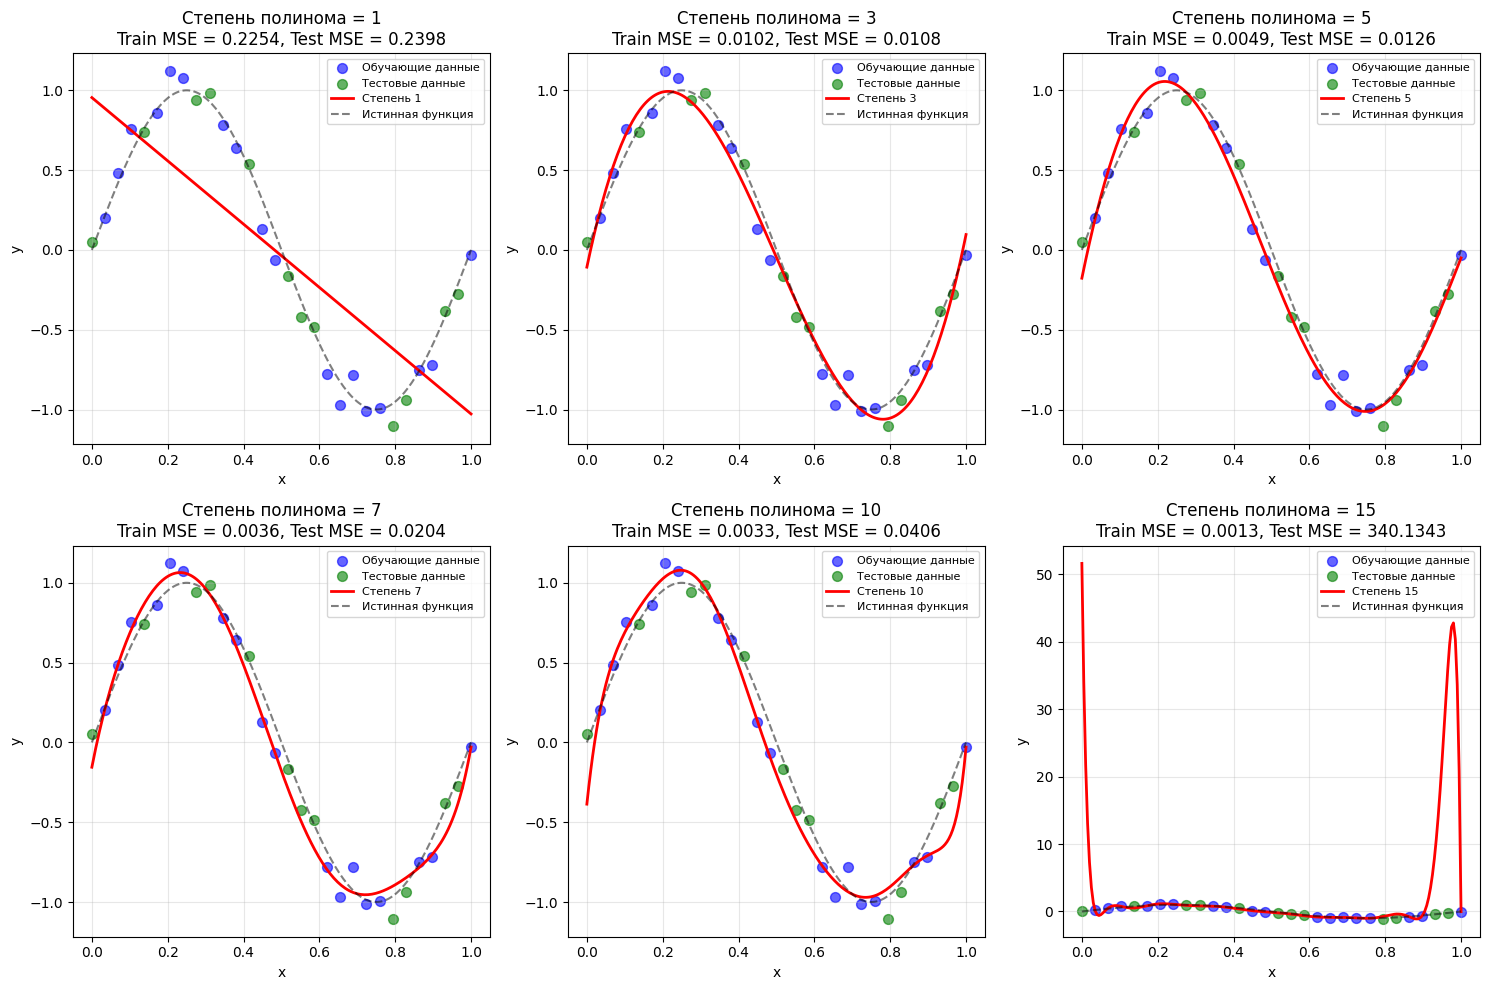

In [38]:
# Визуализация переобучения с разной сложностью модели
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

degrees = [1, 3, 5, 7, 10, 15]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

train_errors = []
test_errors = []

for idx, degree in enumerate(degrees):
    # Создание полиномиальных признаков
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly_features.fit_transform(X_train_demo)
    X_test_poly = poly_features.transform(X_test_demo)
    
    # Обучение линейной регрессии
    model = LinearRegression()
    model.fit(X_train_poly, y_train_demo)
    
    # Предсказание
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # Оценка ошибок
    train_mse = mean_squared_error(y_train_demo, y_train_pred)
    test_mse = mean_squared_error(y_test_demo, y_test_pred)
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    
    # Визуализация
    X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
    X_plot_poly = poly_features.transform(X_plot)
    y_plot_pred = model.predict(X_plot_poly)
    
    axes[idx].scatter(X_train_demo, y_train_demo, color='blue', alpha=0.6, label='Обучающие данные', s=50)
    axes[idx].scatter(X_test_demo, y_test_demo, color='green', alpha=0.6, label='Тестовые данные', s=50)
    axes[idx].plot(X_plot, y_plot_pred, 'r-', linewidth=2, label=f'Степень {degree}')
    axes[idx].plot(X_plot, np.sin(2 * np.pi * X_plot), 'k--', alpha=0.5, label='Истинная функция')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    axes[idx].set_title(f'Степень полинома = {degree}\nTrain MSE = {train_mse:.4f}, Test MSE = {test_mse:.4f}')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

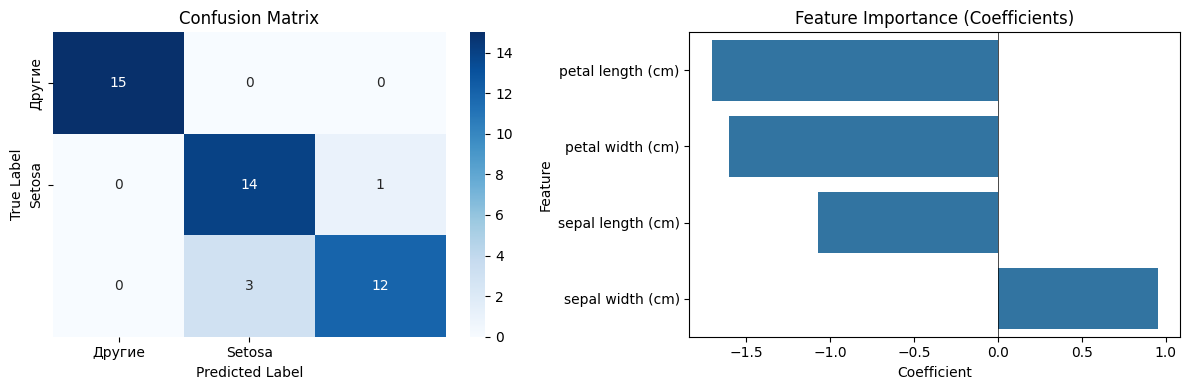

In [39]:
# Визуализация результатов
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Другие', 'Setosa'],
            yticklabels=['Другие', 'Setosa'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Коэффициенты модели
coef_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

sns.barplot(data=coef_df, x='Coefficient', y='Feature', ax=axes[1])
axes[1].set_title('Feature Importance (Coefficients)')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

Метод k-ближайших соседей (KNN)

In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print("\nKNN Results:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


KNN Results:
[[105]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105

Accuracy: 1.0


Дерево решений

In [29]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred = dt.predict(X_test_scaled)

print("\nDecision Tree Results:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Decision Tree Results:
[[105]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105

Accuracy: 1.0


Случайный лес

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

print("\nRandom Forest Results:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Random Forest Results:
[[105]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105

Accuracy: 1.0


In [31]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values())
plt.title('Model Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0)
plt.show()

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0

 Метод опорных векторов (SVM)

In [28]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Линейное ядро
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred = svm_linear.predict(X_test_scaled)

print("SVM (Linear Kernel) Results:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

# Гауссово ядро (RBF)
svm_rbf = SVC(kernel='rbf', gamma='scale', C=1.0, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
y_pred = svm_rbf.predict(X_test_scaled)

print("SVM (RBF Kernel) Results:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

SVM (Linear Kernel) Results:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Accuracy: 0.9111

SVM (RBF Kernel) Results:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

Accuracy: 0.9333



Наивный Байес (Gaussian Naive Bayes

In [29]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)  # Для Naive Bayes масштабирование не обязательно
y_pred = nb.predict(X_test_scaled)

print("Gaussian Naive Bayes Results:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

Gaussian Naive Bayes Results:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Accuracy: 0.9111



Градиентный бустинг (Gradient Boosting)

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, 
                               max_depth=3, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred = gb.predict(X_test_scaled)

print("Gradient Boosting Results:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

Gradient Boosting Results:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.83      1.00      0.91        15
   virginica       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45

Accuracy: 0.9333



Дополнительно: XGBoost (экстремальный градиентный бустинг)

In [31]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Преобразуем строковые метки в числовые
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, 
                   max_depth=3, random_state=42)
xgb.fit(X_train_scaled, y_train_encoded)
y_pred_encoded = xgb.predict(X_test_scaled)

# Обратное преобразование для читаемого вывода
y_pred = label_encoder.inverse_transform(y_pred_encoded)

print("XGBoost Results:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

XGBoost Results:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

Accuracy: 0.9333



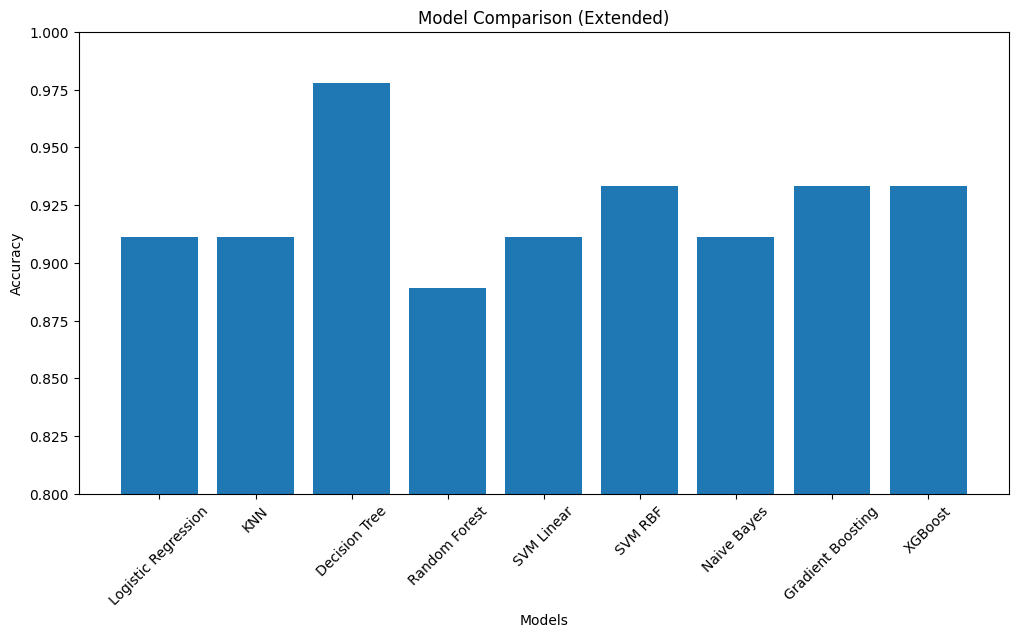

In [32]:
# Преобразуем все метки для единообразия
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM Linear': SVC(kernel='linear', C=1.0, random_state=42),
    'SVM RBF': SVC(kernel='rbf', gamma='scale', C=1.0, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

results = {}
for name, model in models.items():
    if name == 'Naive Bayes':  # Для Naive Bayes масштабирование не требуется
        model.fit(X_train, y_train_encoded)
        y_pred_encoded = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train_encoded)
        y_pred_encoded = model.predict(X_test_scaled)
    
    # Преобразуем обратно для вычисления метрик
    y_pred = label_encoder.inverse_transform(y_pred_encoded)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

# Визуализация результатов
plt.figure(figsize=(12, 6))
plt.bar(results.keys(), results.values())
plt.title('Model Comparison (Extended)')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)
plt.show()